### Combining pharm stats for England and Spain

In [123]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.dates import date2num
import pandas as pd

In [124]:
dfe = pd.read_csv('./data/England_antidepressants_and_anxiolytics_21_25.csv')
dfs = pd.read_csv('./data/Spain_antidepressants_and_anxiolytics_21_25.csv')

In [ ]:
# summing chemical_substance column for group (antidepressants and anxiolytics) per month
dfe_clean = dfe.groupby(['date', 'country', 'group'], as_index=False).agg(
    items_1000=('items_1000', 'sum'),
    items=('items', 'sum')
)
print(dfe_clean.tail(2))
print(dfs.head(2))

        date  country            group  items_1000      items
118  2025-12  England  Antidepressants    8383.184  8383184.0
119  2025-12  England      Anxiolytics    2216.274  2216274.0
      date country            group  items_1000      items
0  2021-01   Spain      Anxiolytics     4802.61  4802610.0
1  2021-01   Spain  Antidepressants     3892.41  3892410.0


In [ ]:
# concating two tables
df_pharm_all = pd.concat([dfe_clean, dfs])
df_pharm_all.head(2)

,date,country,group,items_1000,items
0,2021-01,England,Antidepressants,6694.824,6694824.0
1,2021-01,England,Anxiolytics,1959.228,1959228.0


### Joining Population stats to Pharm stats

In [127]:
pop = pd.read_csv('./data/Population_monthly_21_25_all.csv')
pop.tail(2)

,date,population,country
118,2025-11,47918364,Spain
119,2025-12,47921205,Spain


In [ ]:
# joining tables based on date and country
df_pharm_pop = df_pharm_all.merge(pop, on=['date', 'country'], how='left')
df_pharm_pop.head(2)

,date,country,group,items_1000,items,population
0,2021-01,England,Antidepressants,6694.824,6694824.0,56489800
1,2021-01,England,Anxiolytics,1959.228,1959228.0,56489800


In [134]:
# ensure datetime to avoid wrong calculations 
df_pharm_pop['date'] = pd.to_datetime(df_pharm_pop['date'])

# normalize per 1000 people
df_pharm_pop['items_per_1k'] = round((df_pharm_pop['items'] /(df_pharm_pop['population'])) * 1000,2)

# add days in month
df_pharm_pop['days_in_month'] = df_pharm_pop['date'].dt.days_in_month

# normalize per 1000 people per day
df_pharm_pop['items_per_1k_per_day'] = round((df_pharm_pop['items'] /(df_pharm_pop['population'] * df_pharm_pop['days_in_month'])) * 1000,2)

df_pharm_pop.head(4)

,date,country,group,items_1000,items,population,days_in_month,items_per_1k,items_per_1k_per_day
0,2021-01-01,England,Antidepressants,6694.824,6694824.0,56489800,31,118.51,3.82
1,2021-01-01,England,Anxiolytics,1959.228,1959228.0,56489800,31,34.68,1.12
2,2021-02-01,England,Antidepressants,6321.942,6321942.0,56541183,28,111.81,3.99
3,2021-02-01,England,Anxiolytics,1855.231,1855231.0,56541183,28,32.81,1.17


### First visualisation
Monthly prescription rates of antidepressants and anxiolytics in England and Spain (2021–2025), including linear trend lines to illustrate long-term prescribing patterns over time.

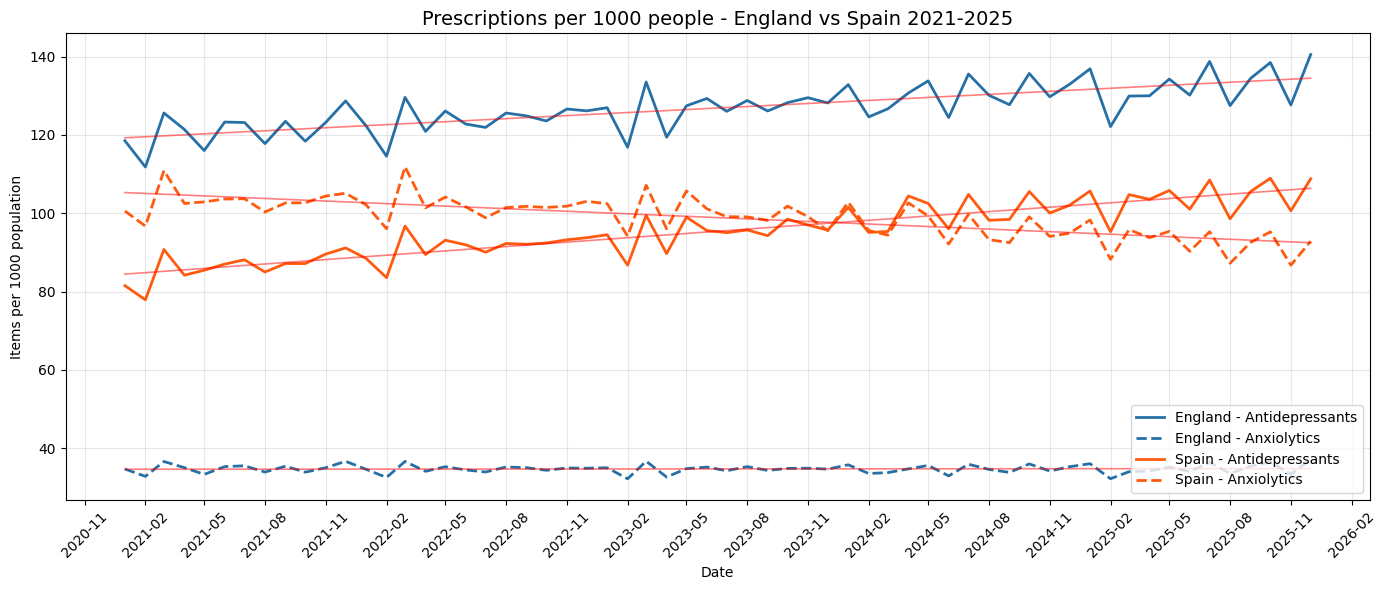

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(['England', 'Spain'], ["#2670A6", "#ff5a0e"]):
    for group, linestyle in zip(['Antidepressants', 'Anxiolytics'], ['-', '--']):
        df_c = df_pharm_pop[(df_pharm_pop['country'] == country) & 
                         (df_pharm_pop['group'] == group)].sort_values('date')
        # Main line
        ax.plot(df_c['date'], df_c['items_per_1k'], 
                label=f'{country} - {group}',
                color=color, linestyle=linestyle, linewidth=2)
        # Trend line
        x_num = date2num(df_c['date'].values)
        z = np.polyfit(x_num, df_c['items_per_1k'], 1)
        p = np.poly1d(z)
        ax.plot(df_c['date'], p(x_num),
                color='red', linestyle='-', linewidth=1.2, alpha=0.5)
ax.set_title('Prescriptions per 1000 people - England vs Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Items per 1000 population')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

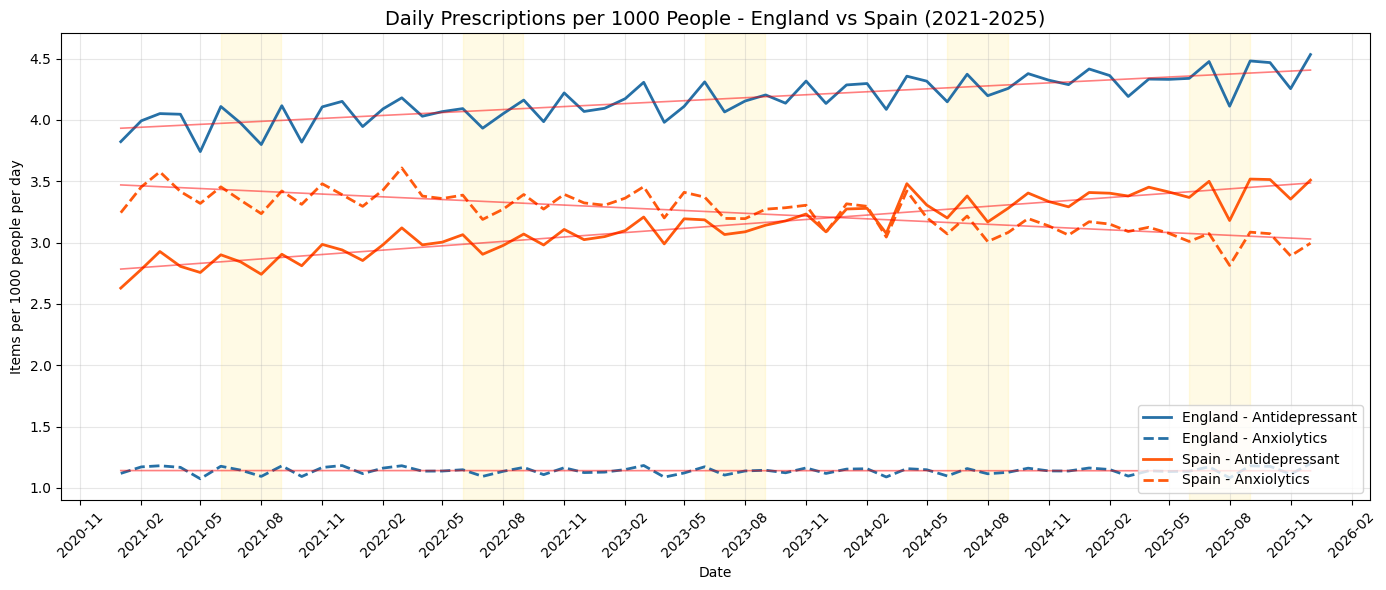

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
# ---- Summer shading ----
years = range(2021, 2026)

for year in years:
    
    summer_start = pd.Timestamp(f'{year}-06-01')
    summer_end = pd.Timestamp(f'{year}-08-31')
    
    ax.axvspan(
        summer_start,
        summer_end,
        alpha=0.1,
        color='gold'
    )
# ---- Plot lines ----
for country, color in zip(
    ['England', 'Spain'],
    ["#2670A6", "#ff5a0e"]
):
    for group, linestyle in zip(
        ['Antidepressant', 'Anxiolytics'],
        ['-', '--']
    ):
        df_c = df_merged[
            (df_merged['country'] == country) &
            (df_merged['group'] == group)
        ].sort_values('date')
        # main line
        ax.plot(
            df_c['date'],
            df_c['items_per_1k_day'],
            label=f'{country} - {group}',
            color=color,
            linestyle=linestyle,
            linewidth=2
        )
        # trend line
        x_num = date2num(df_c['date'].values)
        z = np.polyfit(
            x_num,
            df_c['items_per_1k_day'],
            1
        )
        p = np.poly1d(z)
        ax.plot(
            df_c['date'],
            p(x_num),
            color='red',
            linestyle='-',
            linewidth=1.2,
            alpha=0.5
        )
ax.set_title(
    'Daily Prescriptions per 1000 People - England vs Spain (2021-2025)',
    fontsize=14
)
ax.set_xlabel('Date')
ax.set_ylabel('Items per 1000 people per day')
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)
plt.xticks(rotation=45)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
print(df_merged[df_merged['country'] == 'Spain']['group'].unique())
print(df_merged[df_merged['country'] == 'Spain']['group'].value_counts())

<ArrowStringArray>
['Anxiolytics', 'Antidepressants']
Length: 2, dtype: str
group
Anxiolytics        60
Antidepressants    60
Name: count, dtype: int64


In [80]:
df_w = pd.read_csv('./data/all_weather_clean.csv')
df_w.head(2)

,date,tavg,tmin,tmax,prcp,pres,tsun,station_name
0,2023-07,15.9,13.2,18.5,NaN,1006.9,8138.0,Sunderland
1,2024-01,5.3,3.6,7.1,NaN,1013.2,3962.0,Sunderland


In [ ]:
df_w['station_name'].unique()

<ArrowStringArray>
[            'Sunderland',    'Newcastle upon Tyne',                  'Leeds',
                'Bristol',                 'London',          'Middlesbrough',
             'Manchester',                   'York',             'Nottingham',
           'Peterborough',             'Birmingham',               'Plymouth',
                 'Exeter',               'Brighton',             'Canterbury',
                 'Bilbao', 'Santiago de Compostela',               'Valencia',
              'Barcelona',                'Seville',                 'Malaga',
                 'Madrid',               'Zaragoza']
Length: 23, dtype: str


In [ ]:
england_cities = [
    'Sunderland', 'Newcastle upon Tyne', 'Leeds', 'Bristol', 'London',
    'Middlesbrough', 'Manchester', 'York', 'Nottingham', 'Peterborough',
    'Birmingham', 'Plymouth', 'Exeter', 'Brighton', 'Canterbury'
]
spain_cities = [
    'Bilbao', 'Santiago de Compostela', 'Valencia', 'Barcelona',
    'Seville', 'Malaga', 'Madrid', 'Zaragoza'
]
# Add country column
df_w['country'] = df_w['station_name'].apply(
    lambda x: 'England' if x in england_cities else ('Spain' if x in spain_cities else 'Unknown')
)
# Calculate average and std per month per country
df_weather_agg = df_w.groupby(['date', 'country']).agg(
    tavg_mean=('tavg', 'mean'),
    tavg_std=('tavg', 'std'),
    tmin_mean=('tmin', 'mean'),
    tmin_std=('tmin', 'std'),
    tmax_mean=('tmax', 'mean'),
    tmax_std=('tmax', 'std'),
    prcp_mean=('prcp', 'mean'),
    prcp_std=('prcp', 'std'),
    pres_mean=('pres', 'mean'),
    pres_std=('pres', 'std'),
    tsun_mean=('tsun', 'mean'),
    tsun_std=('tsun', 'std')
).round(1).reset_index()

df_weather_agg.head()

,date,country,tavg_mean,tavg_std,tmin_mean,tmin_std,tmax_mean,tmax_std,prcp_mean,prcp_std,pres_mean,pres_std,tsun_mean,tsun_std
0,2021-01,England,3.5,1.2,1.2,1.2,5.6,1.2,98.1,33.5,1010.6,0.9,3139.6,1011.8
1,2021-01,Spain,8.5,2.7,4.1,2.8,12.8,3.0,97.1,71.9,1017.8,1.8,8581.9,3109.1
2,2021-02,England,5.2,0.8,2.6,0.9,7.7,0.9,65.2,22.2,1013.9,1.0,3926.1,680.2
3,2021-02,Spain,12.4,1.9,8.1,2.1,16.7,1.9,69.5,96.6,1017.9,1.4,7773.8,1835.5
4,2021-03,England,7.2,0.5,3.9,0.6,10.5,0.6,54.0,33.4,1020.6,1.8,6518.8,1451.7


In [22]:
df_w[df_w['date'] == '2021-01'][['station_name', 'tsun']].sort_values('station_name')

,station_name,tsun
1029,Barcelona,7635.0
849,Bilbao,2640.0
282,Birmingham,4042.0
843,Brighton,1770.0
805,Bristol,1764.0
845,Canterbury,2106.0
382,Exeter,4184.0
735,Leeds,2382.0
824,London,1764.0
1209,Madrid,9000.0


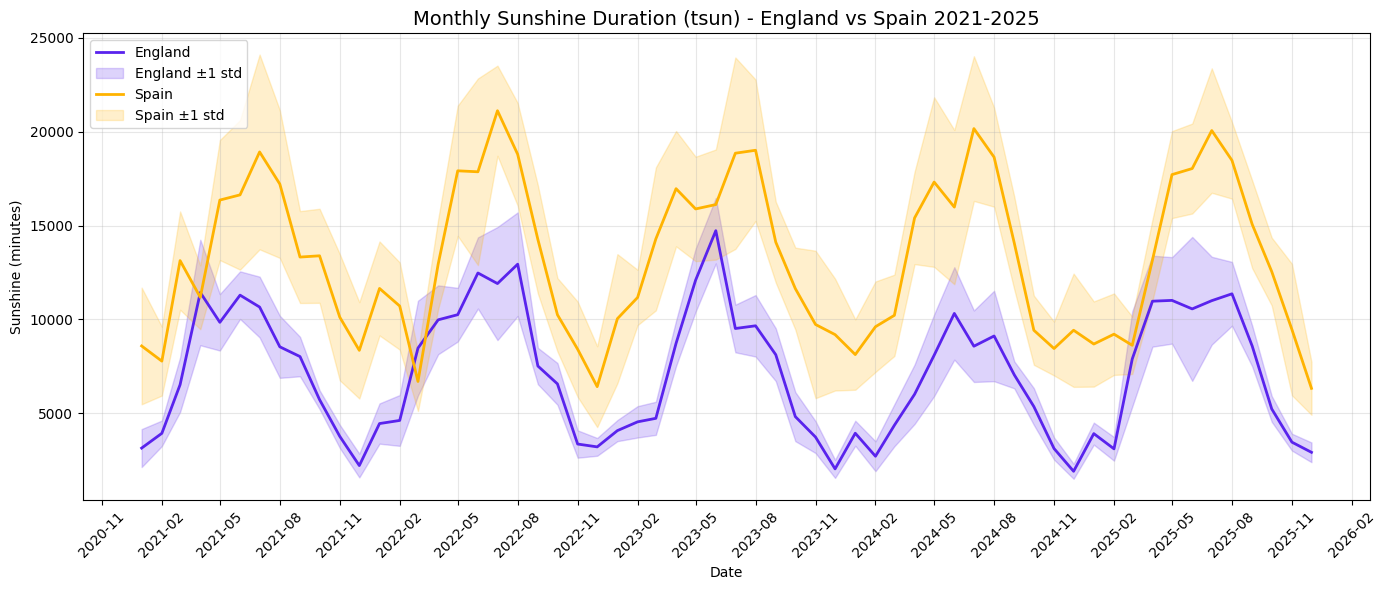

In [ ]:
# Convert date to datetime for proper x-axis
df_weather_agg['date'] = pd.to_datetime(df_weather_agg['date'])

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(['England', 'Spain'], ["#5923ed", "#ffb300"]):
    df_c = df_weather_agg[df_weather_agg['country'] == country].sort_values('date')
    
    # Line
    ax.plot(df_c['date'], df_c['tsun_mean'], label=country, color=color, linewidth=2)
    
    # Std band
    ax.fill_between(
        df_c['date'],
        df_c['tsun_mean'] - df_c['tsun_std'],
        df_c['tsun_mean'] + df_c['tsun_std'],
        alpha=0.2,
        color=color,
        label=f'{country} ±1 std'
    )

ax.set_title('Monthly Sunshine Duration (tsun) - England vs Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sunshine (minutes)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(['England', 'Spain'], ['#1f77b4', '#ff7f0e']):
    df_c = df_weather_agg[df_weather_agg['country'] == country].sort_values('date')
    
    ax.plot(df_c['date'], df_c['prcp_mean'], label=country, color=color, linewidth=2)
    
    ax.fill_between(
        df_c['date'],
        df_c['prcp_mean'] - df_c['prcp_std'],
        df_c['prcp_mean'] + df_c['prcp_std'],
        alpha=0.2,
        color=color,
        label=f'{country} ±1 std'
    )

ax.set_title('Monthly Precipitation (prcp) - England vs Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_merged = df.merge(pop, on=['date', 'country'], how='left')
df_merged.head(2)

In [ ]:
england_cities = [
    'Sunderland', 'Newcastle upon Tyne', 'Leeds', 'Bristol', 'London',
    'Middlesbrough', 'Manchester', 'York', 'Nottingham', 'Peterborough',
    'Birmingham', 'Plymouth', 'Exeter', 'Brighton', 'Canterbury'
]

spain_cities = [
    'Bilbao', 'Santiago de Compostela', 'Valencia', 'Barcelona',
    'Seville', 'Malaga', 'Madrid', 'Zaragoza'
]

# Add country column
df_w['country'] = df_w['station_name'].apply(
    lambda x: 'England' if x in england_cities else ('Spain' if x in spain_cities else 'Unknown')
)

# Calculate average and std per month per country
df_weather_agg_mean_median = df_w.groupby(['date', 'country']).agg(
    tavg_mean=('tavg', 'mean'),
    tavg_median=('tavg', 'median'),
    tavg_std=('tavg', 'std'),
    tmin_mean=('tmin', 'mean'),
    tmin_median=('tmin', 'median'),
    tmin_std=('tmin', 'std'),
    tmax_mean=('tmax', 'mean'),
    tmax_median=('tmax', 'median'),
    tmax_std=('tmax', 'std'),
    prcp_mean=('prcp', 'mean'),
    prcp_median=('prcp', 'median'),
    prcp_std=('prcp', 'std'),
    tsun_mean=('tsun', 'mean'),
    tsun_median=('tsun', 'median'),
    tsun_std=('tsun', 'std')
).round(1).reset_index()


df_weather_agg_mean_median.head()

,date,country,tavg_mean,tavg_median,tavg_std,tmin_mean,tmin_median,tmin_std,tmax_mean,tmax_median,tmax_std,prcp_mean,prcp_median,prcp_std,tsun_mean,tsun_median,tsun_std
0,2021-01,England,3.5,3.1,1.2,1.2,0.8,1.2,5.6,5.3,1.2,98.1,93.5,33.5,3139.6,3468.0,1011.8
1,2021-01,Spain,8.5,8.7,2.7,4.1,4.6,2.8,12.8,12.6,3.0,97.1,68.0,71.9,8581.9,9510.0,3109.1
2,2021-02,England,5.2,4.9,0.8,2.6,2.5,0.9,7.7,7.8,0.9,65.2,62.5,22.2,3926.1,3936.0,680.2
3,2021-02,Spain,12.4,12.8,1.9,8.1,9.0,2.1,16.7,16.7,1.9,69.5,34.0,96.6,7773.8,8400.0,1835.5
4,2021-03,England,7.2,7.1,0.5,3.9,3.8,0.6,10.5,10.5,0.6,54.0,42.5,33.4,6518.8,6438.0,1451.7


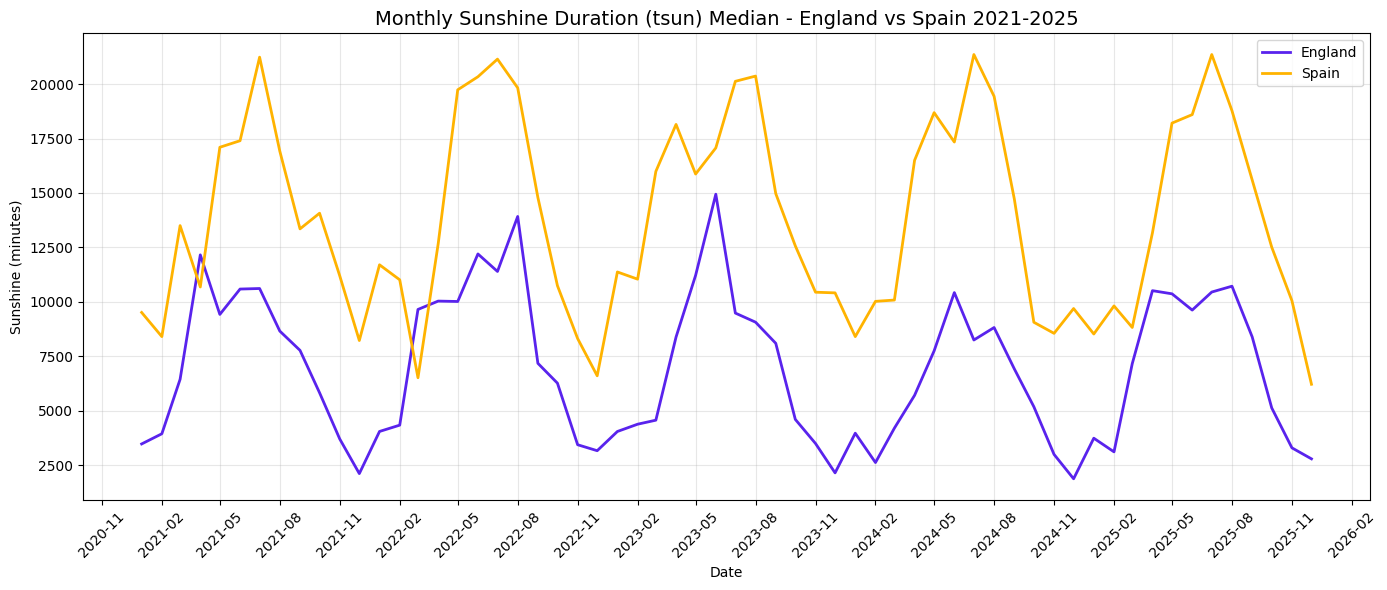

In [64]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df_weather_agg_mean_median['date'] = pd.to_datetime(df_weather_agg_mean_median['date'])

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(['England', 'Spain'], ["#5923ed", "#ffb300"]):
    df_c = df_weather_agg_mean_median[df_weather_agg_mean_median['country'] == country].sort_values('date')
    
    ax.plot(df_c['date'], df_c['tsun_median'], label=country, color=color, linewidth=2)

ax.set_title('Monthly Sunshine Duration (tsun) Median - England vs Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sunshine (minutes)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
df_all = df_merged.merge(df_weather_agg_mean_median, on=['date', 'country'], how='left')
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          240 non-null    datetime64[us]
 1   country       240 non-null    str           
 2   group         240 non-null    str           
 3   items_1000    240 non-null    float64       
 4   items         240 non-null    float64       
 5   population    240 non-null    int64         
 6   items_per_1k  240 non-null    float64       
 7   tavg_mean     240 non-null    float64       
 8   tavg_median   240 non-null    float64       
 9   tavg_std      240 non-null    float64       
 10  tmin_mean     240 non-null    float64       
 11  tmin_median   240 non-null    float64       
 12  tmin_std      240 non-null    float64       
 13  tmax_mean     240 non-null    float64       
 14  tmax_median   240 non-null    float64       
 15  tmax_std      240 non-null    float64       
 16  p

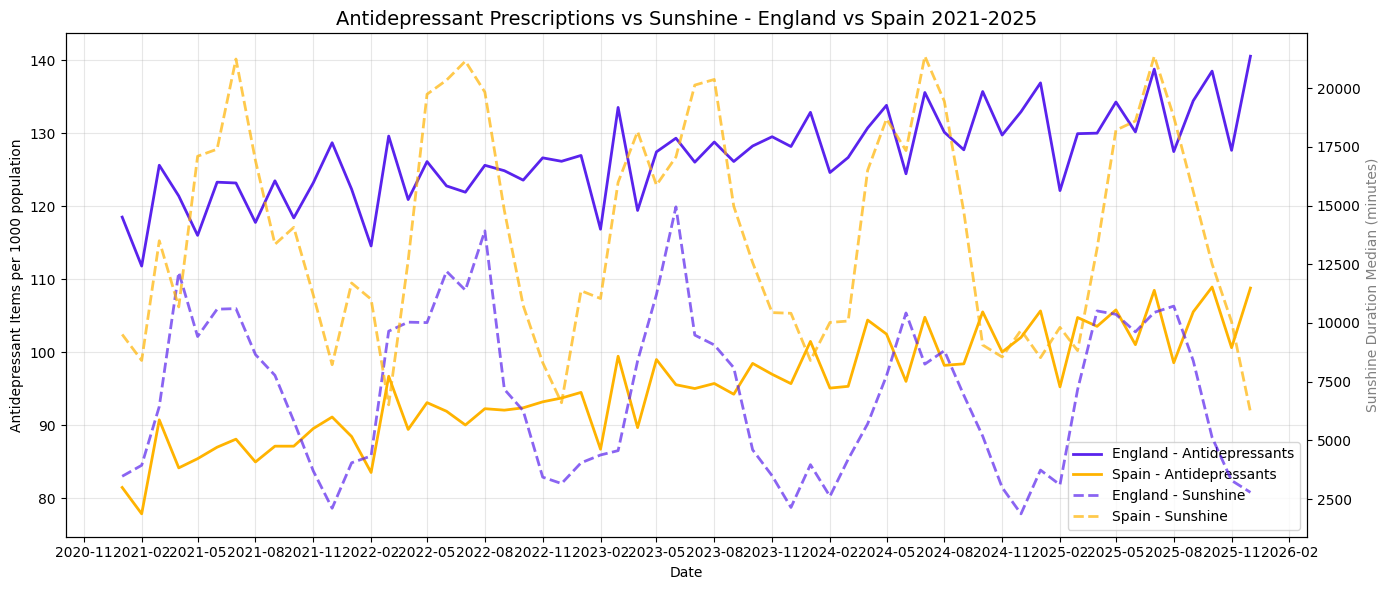

In [68]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()  # second y-axis

for country, color in zip(['England', 'Spain'], ["#5923ed", "#ffb300"]):
    df_c = df_all[(df_all['country'] == country) & 
                  (df_all['group'] == 'Antidepressant')].sort_values('date')
    
    # Antidepressants on left y-axis
    ax1.plot(df_c['date'], df_c['items_per_1k'],
             label=f'{country} - Antidepressants',
             color=color, linestyle='-', linewidth=2)
    
    # Tsun median on right y-axis
    ax2.plot(df_c['date'], df_c['tsun_median'],
             label=f'{country} - Sunshine',
             color=color, linestyle='--', linewidth=2, alpha=0.7)

ax1.set_xlabel('Date')
ax1.set_ylabel('Antidepressant Items per 1000 population', color='black')
ax2.set_ylabel('Sunshine Duration Median (minutes)', color='grey')
ax1.set_title('Antidepressant Prescriptions vs Sunshine - England vs Spain 2021-2025', fontsize=14)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

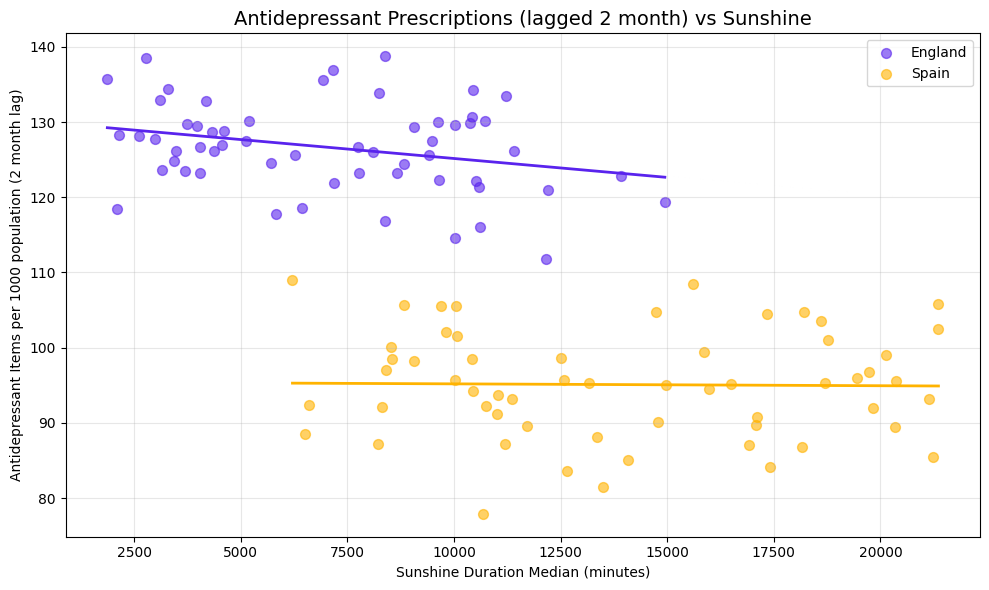

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))

for country, color in zip(['England', 'Spain'], ["#5923ed", "#ffb300"]):
    df_c = df_all[(df_all['country'] == country) & 
                  (df_all['group'] == 'Antidepressant')].sort_values('date').copy()
    
    # Shift prescriptions by 1 month (lag)
    df_c['items_per_1k_lagged'] = df_c['items_per_1k'].shift(2)
    df_c = df_c.dropna()  # drop first row which becomes NaN
    
    ax.scatter(df_c['tsun_median'], df_c['items_per_1k_lagged'],
               label=country, color=color, alpha=0.6, s=50)
    
    # Trend line
    z = np.polyfit(df_c['tsun_median'], df_c['items_per_1k_lagged'], 1)
    p = np.poly1d(z)
    x_sorted = df_c['tsun_median'].sort_values()
    ax.plot(x_sorted, p(x_sorted), color=color, linewidth=2)

ax.set_xlabel('Sunshine Duration Median (minutes)')
ax.set_ylabel('Antidepressant Items per 1000 population (2 month lag)')
ax.set_title('Antidepressant Prescriptions (lagged 2 month) vs Sunshine', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()